In [ ]:
!pip install opencv-python

In [12]:
pip install opencv-python matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install numpy==1.26.4

Note: you may need to restart the kernel to use updated packages.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

path = r"C:\Users\Zoya\Desktop\PAI LAB\TASK-5\zoya.jpeg"
img = cv2.imread(path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

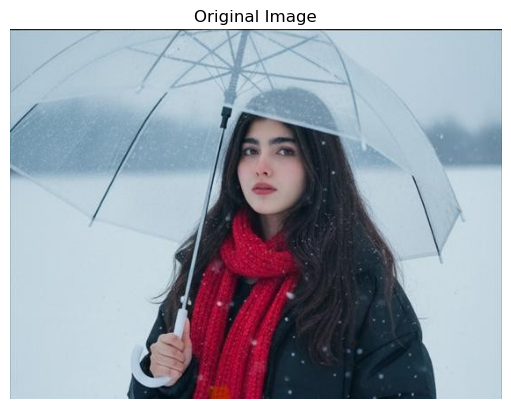

In [3]:
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

## Blurring (Gaussian + Median)

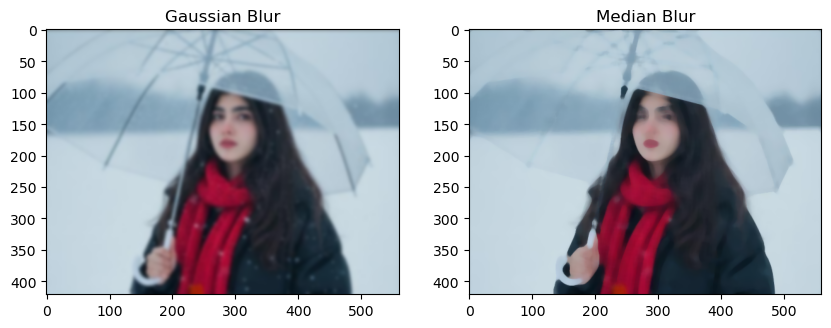

In [6]:
gaussian = cv2.GaussianBlur(img, (15,15), 0)
median = cv2.medianBlur(img, 11)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB))
plt.title("Gaussian Blur")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(median, cv2.COLOR_BGR2RGB))
plt.title("Median Blur")

plt.show()

## Grayscale

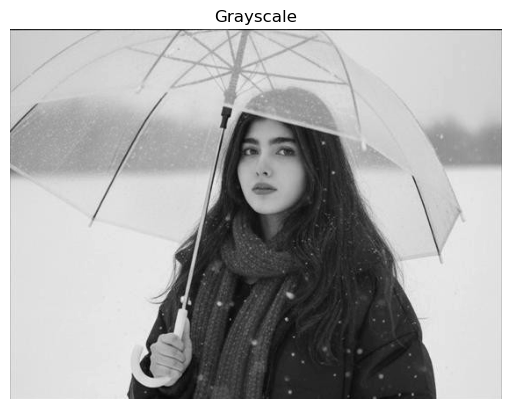

In [9]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()

## Resize

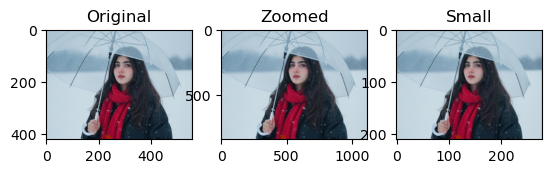

In [14]:
small = cv2.resize(img_rgb, None, fx=0.5, fy=0.5)
big = cv2.resize(img_rgb, None, fx=2, fy=2)

plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(big); plt.title("Zoomed")
plt.subplot(1,3,3); plt.imshow(small); plt.title("Small")
plt.show()

## Rotation

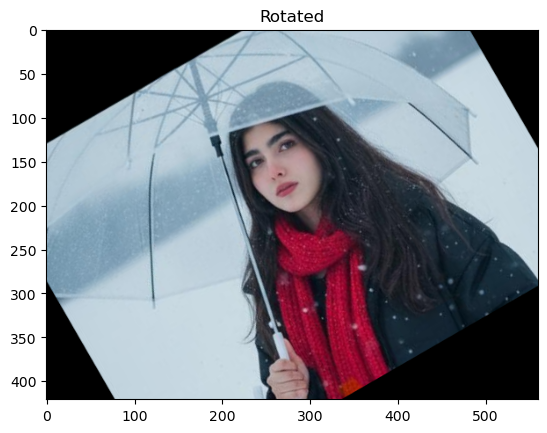

In [19]:
h, w = img.shape[:2]
center = (w//2, h//2)
M = cv2.getRotationMatrix2D(center, 30, 1)
rotated = cv2.warpAffine(img_rgb, M, (w,h))

plt.imshow(rotated)
plt.title("Rotated")
plt.show()

## Translation

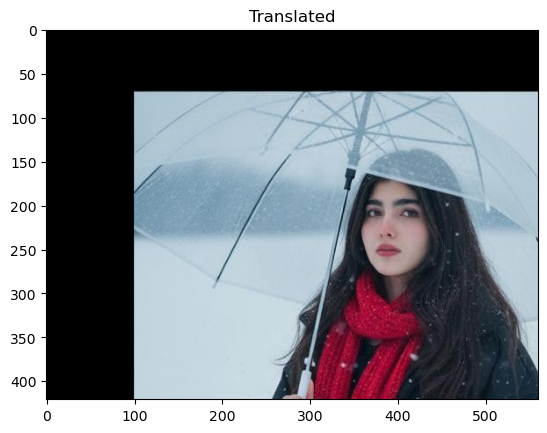

In [22]:
T = np.float32([[1,0,100],[0,1,70]])
translated = cv2.warpAffine(img_rgb, T, (w,h))

plt.imshow(translated)
plt.title("Translated")
plt.show()

## Shearing

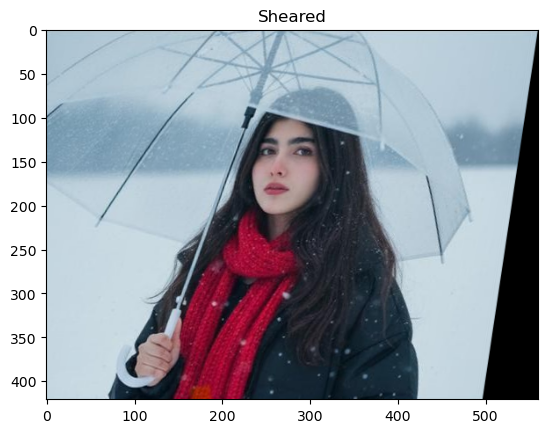

In [25]:
S = np.float32([[1,-0.15,0],[0,1,0]])
sheared = cv2.warpAffine(img_rgb, S, (w,h))

plt.imshow(sheared)
plt.title("Sheared")
plt.show()

## Normalization 

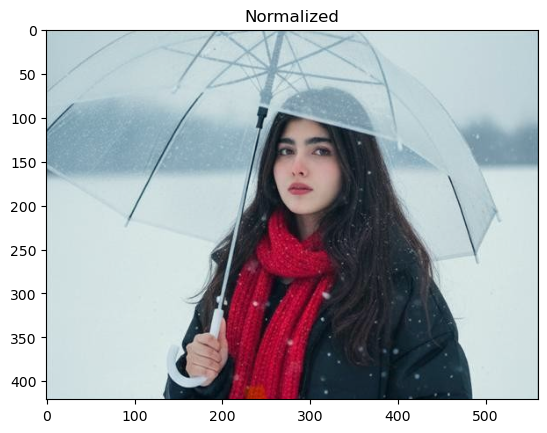

In [28]:
b,g,r = cv2.split(img_rgb)

b = cv2.normalize(b.astype('float'),None,0,1,cv2.NORM_MINMAX)
g = cv2.normalize(g.astype('float'),None,0,1,cv2.NORM_MINMAX)
r = cv2.normalize(r.astype('float'),None,0,1,cv2.NORM_MINMAX)

norm = cv2.merge((b,g,r))

plt.imshow(norm)
plt.title("Normalized")
plt.show()

## Edge Detection

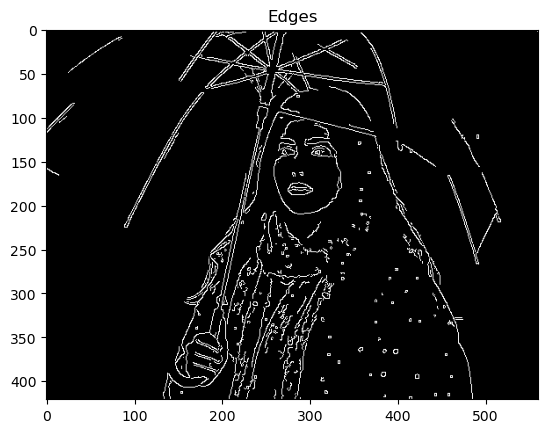

In [34]:
edges = cv2.Canny(img,100,200)
plt.imshow(edges,cmap='gray')
plt.title("Edges")
plt.show()

## Morphology 

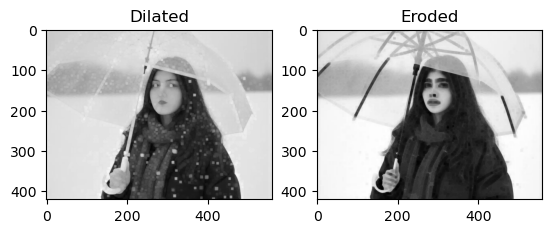

In [41]:
kernel = np.ones((3,3),np.uint8)

dil = cv2.dilate(gray,kernel,iterations=2)
ero = cv2.erode(gray,kernel,iterations=2)

plt.subplot(1,2,1); plt.imshow(dil,cmap='gray'); plt.title("Dilated")
plt.subplot(1,2,2); plt.imshow(ero,cmap='gray'); plt.title("Eroded")
plt.show()

## Log Transform

In [44]:
c = 255/(np.log(1+np.max(img)))
log = c*np.log(1+img)
log = np.array(log,dtype=np.uint8)

cv2.imwrite("log.jpg",log)

True

## Gamma

In [47]:
for g in [0.5,1.2,2.2]:
    gamma = np.array(255*(img/255)**g,dtype='uint8')
    cv2.imwrite(f"gamma_{g}.jpg",gamma)

## Threshold

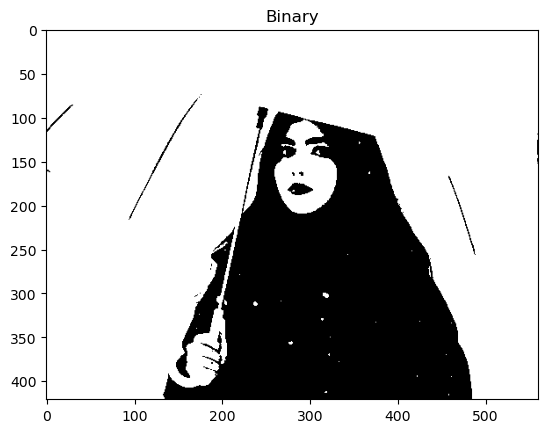

In [50]:
_,th = cv2.threshold(gray,120,255,cv2.THRESH_BINARY)

plt.imshow(th,cmap='gray')
plt.title("Binary")
plt.show()

## Histogram Equalization

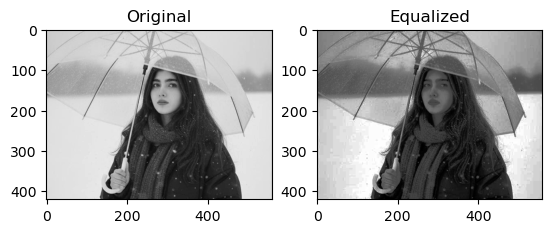

In [53]:
eq = cv2.equalizeHist(gray)

plt.subplot(1,2,1); plt.imshow(gray,cmap='gray'); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(eq,cmap='gray'); plt.title("Equalized")
plt.show()

## Simple Thresholding

In [ ]:
_, binary = cv2.threshold(gray,120,255,cv2.THRESH_BINARY)
_, binary_inv = cv2.threshold(gray,120,255,cv2.THRESH_BINARY_INV)
_, trunc = cv2.threshold(gray,120,255,cv2.THRESH_TRUNC)

plt.subplot(1,3,1); plt.imshow(binary,cmap='gray'); plt.title("Binary")
plt.subplot(1,3,2); plt.imshow(binary_inv,cmap='gray'); plt.title("Inverse")
plt.subplot(1,3,3); plt.imshow(trunc,cmap='gray'); plt.title("Truncated")
plt.show()

## Adaptive Thresholding

In [ ]:
mean = cv2.adaptiveThreshold(gray,255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,199,5)

gauss = cv2.adaptiveThreshold(gray,255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,199,5)

plt.subplot(1,2,1); plt.imshow(mean,cmap='gray'); plt.title("Mean")
plt.subplot(1,2,2); plt.imshow(gauss,cmap='gray'); plt.title("Gaussian")
plt.show()

## Otsu Thresholding

In [ ]:
ret, otsu = cv2.threshold(gray,0,255,
                          cv2.THRESH_BINARY + cv2.THRESH_OTSU)

print("Otsu Value:", ret)

plt.imshow(otsu,cmap='gray')
plt.title("Otsu Threshold")
plt.show()